In [1]:
# === CELL 1: Importing Libraries and Loading Dataset ===

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
from imblearn.over_sampling import SMOTE
import warnings

warnings.filterwarnings('ignore')
print("Libraries imported successfully!")

# Load dataset
try:
    df = pd.read_csv('parkinson_disease.csv')
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print("Error: 'parkinson_disease.csv' not found.")
    raise

# Explore dataset
print(df.head())
df.info()
print(df.describe())
print("Dataset Shape:", df.shape)


Libraries imported successfully!
Dataset loaded successfully!
   id  gender      PPE      DFA     RPDE  numPulses  numPeriodsPulses  \
0   0       1  0.85247  0.71826  0.57227        240               239   
1   0       1  0.76686  0.69481  0.53966        234               233   
2   0       1  0.85083  0.67604  0.58982        232               231   
3   1       0  0.41121  0.79672  0.59257        178               177   
4   1       0  0.32790  0.79782  0.53028        236               235   

   meanPeriodPulses  stdDevPeriodPulses  locPctJitter  ...  \
0          0.008064            0.000087       0.00218  ...   
1          0.008258            0.000073       0.00195  ...   
2          0.008340            0.000060       0.00176  ...   
3          0.010858            0.000183       0.00419  ...   
4          0.008162            0.002669       0.00535  ...   

   tqwt_kurtosisValue_dec_28  tqwt_kurtosisValue_dec_29  \
0                     1.5620                     2.6445   
1       

In [3]:
# === CELL 2: Data Preprocessing ===

X = df.drop(columns=['class', 'id'])
y = df['class']

print("Unique gender values:", df['gender'].unique())

numerical_features = X.select_dtypes(include=np.number).columns.tolist()
if 'gender' in numerical_features:
    numerical_features.remove('gender')

print("Numerical features to scale:", numerical_features)

scaler = StandardScaler()
X[numerical_features] = scaler.fit_transform(X[numerical_features])

print("Scaled features (first 5 rows):")
print(X.head())


Unique gender values: [1 0]
Numerical features to scale: ['PPE', 'DFA', 'RPDE', 'numPulses', 'numPeriodsPulses', 'meanPeriodPulses', 'stdDevPeriodPulses', 'locPctJitter', 'locAbsJitter', 'rapJitter', 'ppq5Jitter', 'ddpJitter', 'locShimmer', 'locDbShimmer', 'apq3Shimmer', 'apq5Shimmer', 'apq11Shimmer', 'ddaShimmer', 'meanAutoCorrHarmonicity', 'meanNoiseToHarmHarmonicity', 'meanHarmToNoiseHarmonicity', 'minIntensity', 'maxIntensity', 'meanIntensity', 'f1', 'f2', 'f3', 'f4', 'b1', 'b2', 'b3', 'b4', 'GQ_prc5_95', 'GQ_std_cycle_open', 'GQ_std_cycle_closed', 'GNE_mean', 'GNE_std', 'GNE_SNR_TKEO', 'GNE_SNR_SEO', 'GNE_NSR_TKEO', 'GNE_NSR_SEO', 'VFER_mean', 'VFER_std', 'VFER_entropy', 'VFER_SNR_TKEO', 'VFER_SNR_SEO', 'VFER_NSR_TKEO', 'VFER_NSR_SEO', 'IMF_SNR_SEO', 'IMF_SNR_TKEO', 'IMF_SNR_entropy', 'IMF_NSR_SEO', 'IMF_NSR_TKEO', 'IMF_NSR_entropy', 'mean_Log_energy', 'mean_MFCC_0th_coef', 'mean_MFCC_1st_coef', 'mean_MFCC_2nd_coef', 'mean_MFCC_3rd_coef', 'mean_MFCC_4th_coef', 'mean_MFCC_5th_coef'

In [5]:
# === CELL 3: Check Class Imbalance + Apply SMOTE ===

print("Class distribution before SMOTE:")
print(y.value_counts())

percent_class_1 = (y.value_counts().get(1.0, 0) / len(y)) * 100
percent_class_0 = (y.value_counts().get(0.0, 0) / len(y)) * 100

print(f"Class 1: {percent_class_1:.2f}%")
print(f"Class 0: {percent_class_0:.2f}%")

minority_fraction = percent_class_0 / 100

if minority_fraction < 0.30:
    print("Applying SMOTE...")
    smote = SMOTE(random_state=42)
    X_resampled, y_resampled = smote.fit_resample(X, y)
    X, y = X_resampled, y_resampled

    print("Class distribution after SMOTE:")
    print(y.value_counts())
else:
    print("No SMOTE needed.")


Class distribution before SMOTE:
class
1    564
0    192
Name: count, dtype: int64
Class 1: 74.60%
Class 0: 25.40%
Applying SMOTE...
Class distribution after SMOTE:
class
1    564
0    564
Name: count, dtype: int64


In [7]:
# === CELL 4: Train-Test Split ===

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Training class distribution:\n", y_train.value_counts(normalize=True))
print("Testing class distribution:\n", y_test.value_counts(normalize=True))


Train shape: (902, 753)
Test shape: (226, 753)
Training class distribution:
 class
1    0.5
0    0.5
Name: proportion, dtype: float64
Testing class distribution:
 class
0    0.5
1    0.5
Name: proportion, dtype: float64


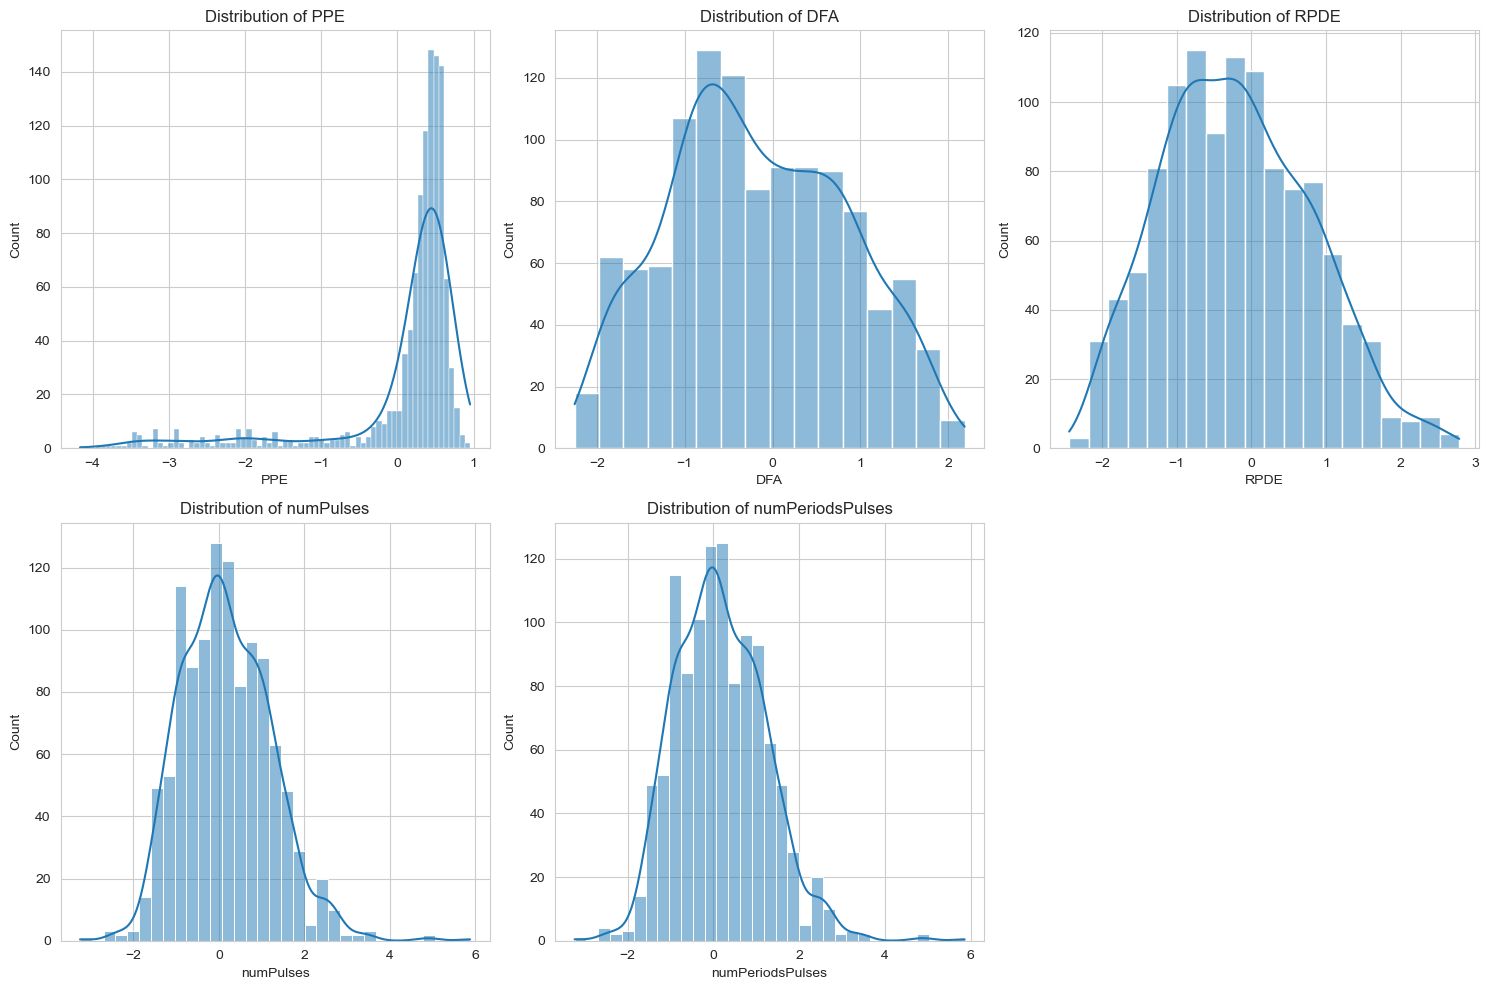

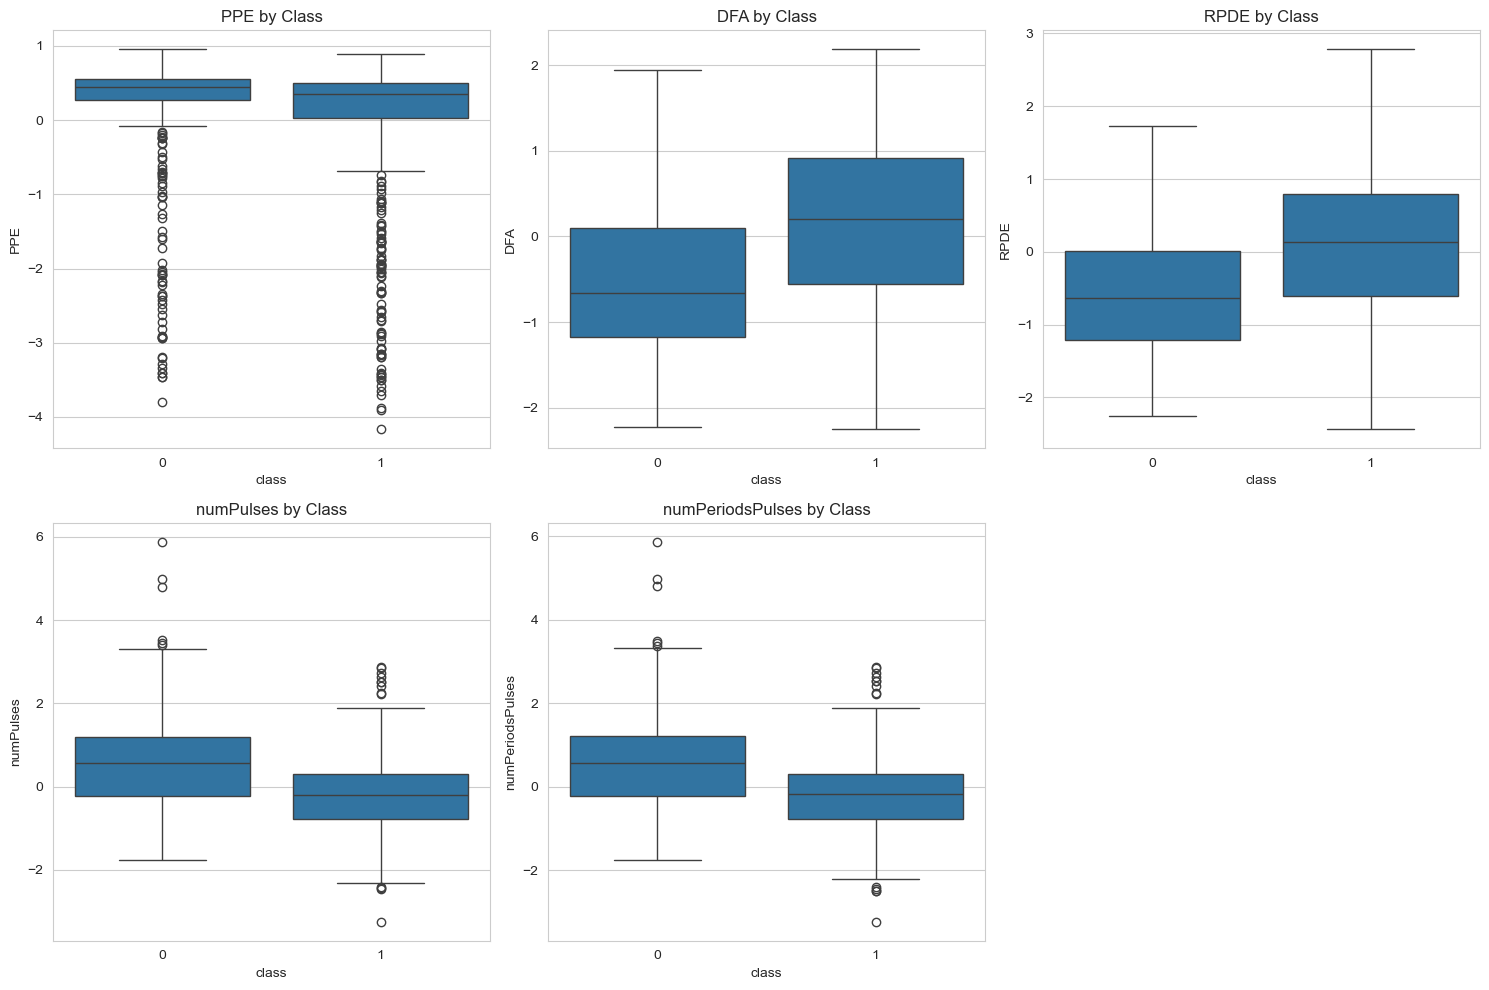

In [9]:
# === CELL 5: Basic EDA ===

df_eda = X.copy()
df_eda['class'] = y

sns.set_style("whitegrid")

features_to_plot = numerical_features[:5]

plt.figure(figsize=(15, 10))
for i, feature in enumerate(features_to_plot):
    plt.subplot(2, 3, i+1)
    sns.histplot(df_eda[feature], kde=True)
    plt.title(f"Distribution of {feature}")
plt.tight_layout()
plt.show()

# Boxplots
plt.figure(figsize=(15, 10))
for i, feature in enumerate(features_to_plot):
    plt.subplot(2, 3, i+1)
    sns.boxplot(x='class', y=feature, data=df_eda)
    plt.title(f"{feature} by Class")
plt.tight_layout()
plt.show()


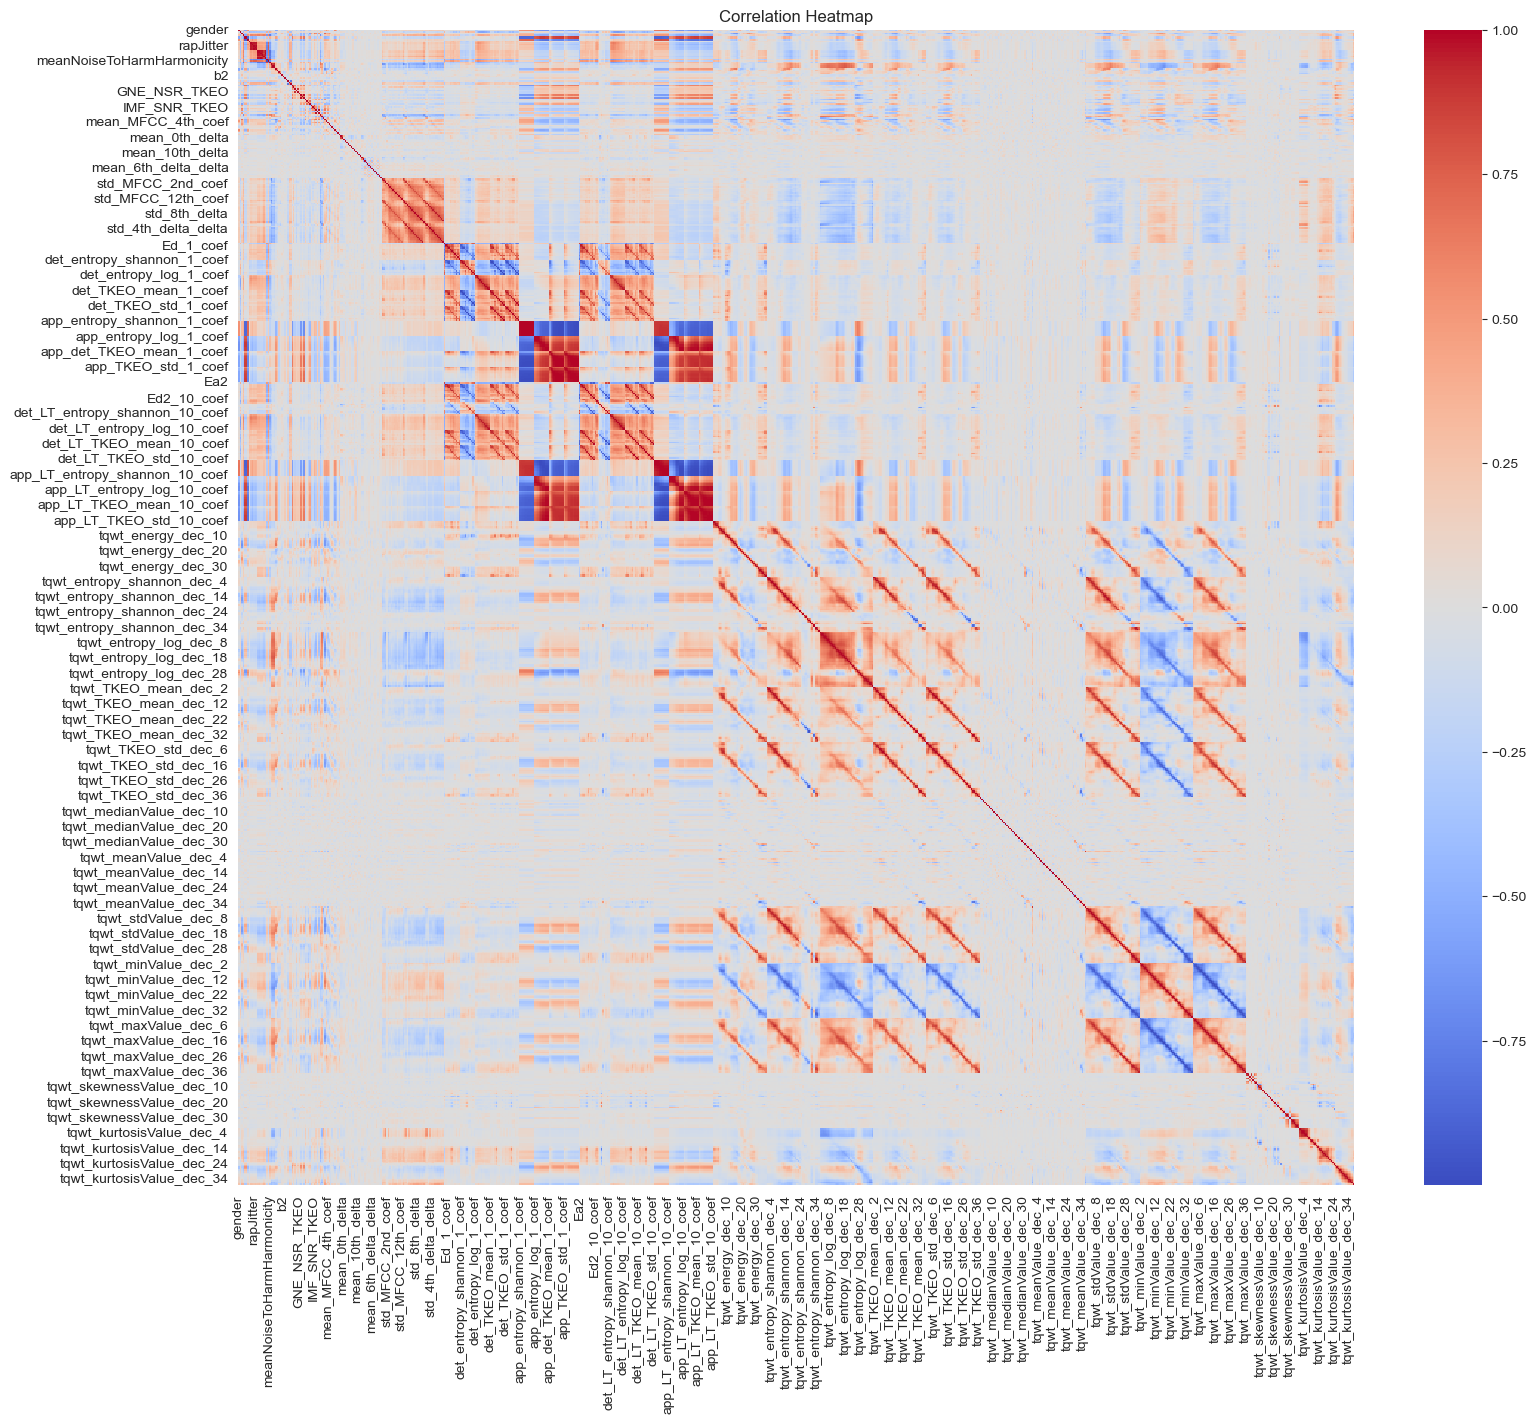

Correlation with class:
class                      1.000000
std_9th_delta_delta        0.483911
std_8th_delta_delta        0.481916
std_7th_delta_delta        0.475194
std_6th_delta_delta        0.465958
                             ...   
tqwt_maxValue_dec_12      -0.403579
tqwt_entropy_log_dec_11   -0.404639
tqwt_entropy_log_dec_16   -0.404806
tqwt_entropy_log_dec_13   -0.425056
tqwt_entropy_log_dec_12   -0.457763
Name: class, Length: 754, dtype: float64


In [11]:
# === CELL 6: Correlation Heatmap ===

correlation_matrix = df_eda.corr()

plt.figure(figsize=(18, 15))
sns.heatmap(correlation_matrix, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

print("Correlation with class:")
print(correlation_matrix['class'].sort_values(ascending=False))


In [13]:
# === CELL 7: Model Training ===

log_reg = LogisticRegression(random_state=42, solver='liblinear')
log_reg.fit(X_train, y_train)

rf_clf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)
rf_clf.fit(X_train, y_train)

svm_clf = SVC(random_state=42, probability=True)
svm_clf.fit(X_train, y_train)

xgb_clf = XGBClassifier(
    n_estimators=100,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb_clf.fit(X_train, y_train)

models = {
    "Logistic Regression": log_reg,
    "Random Forest": rf_clf,
    "Support Vector Machine": svm_clf,
    "XGBoost": xgb_clf
}

print("All models trained successfully.")


All models trained successfully.


In [15]:
# === CELL 8: Evaluation ===

performance_metrics = {}

for name, model in models.items():
    y_pred = model.predict(X_test)

    performance_metrics[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred)
    }

    print(f"\n{name}")
    for metric, value in performance_metrics[name].items():
        print(f"{metric}: {value:.4f}")

best_model_name = max(performance_metrics, key=lambda x: performance_metrics[x]["F1-Score"])
best_model = models[best_model_name]

print(f"\nBest model → {best_model_name}")



Logistic Regression
Accuracy: 0.9336
Precision: 0.9804
Recall: 0.8850
F1-Score: 0.9302

Random Forest
Accuracy: 0.9292
Precision: 0.9533
Recall: 0.9027
F1-Score: 0.9273

Support Vector Machine
Accuracy: 0.9558
Precision: 0.9402
Recall: 0.9735
F1-Score: 0.9565

XGBoost
Accuracy: 0.9602
Precision: 0.9727
Recall: 0.9469
F1-Score: 0.9596

Best model → XGBoost


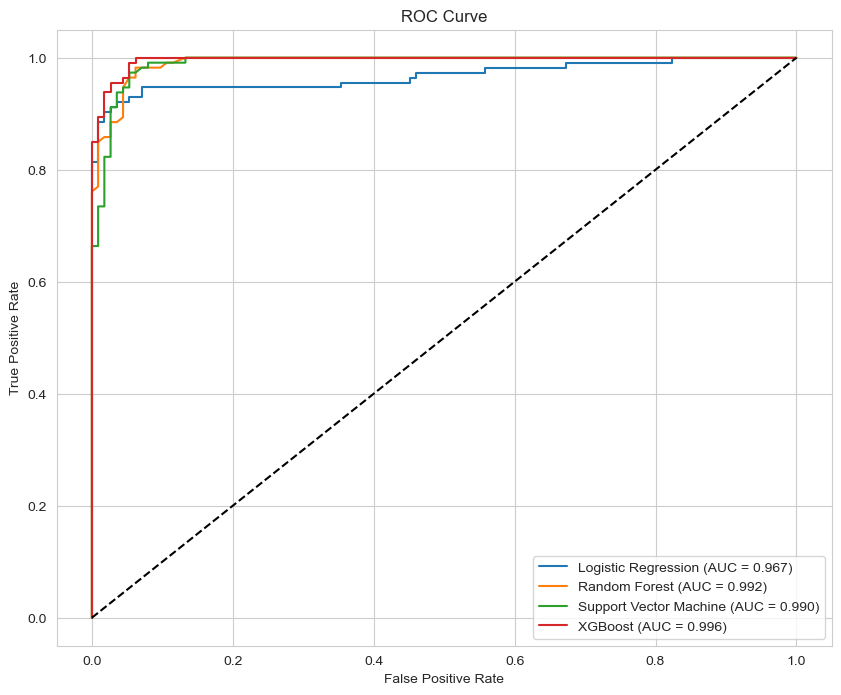

In [17]:
# === CELL 9: ROC Curve ===

plt.figure(figsize=(10, 8))

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


In [19]:
# === CELL 10: Predict New Patient ===

sample = X_test.sample(1)
sample_modified = sample.copy()

if 'PPE' in sample_modified.columns:
    sample_modified['PPE'] *= 1.2

prediction = best_model.predict(sample_modified)
proba = best_model.predict_proba(sample_modified)[:, 1]

print("Sample used:")
print(sample_modified)

if prediction[0] == 1:
    print(f"\nPrediction: Parkinson's (Prob = {proba[0]:.3f})")
else:
    print(f"\nPrediction: No Parkinson's (Prob = {proba[0]:.3f})")


Sample used:
     gender       PPE       DFA      RPDE  numPulses  numPeriodsPulses  \
497       1  0.461084 -0.830377 -1.052756   0.272585          0.275039   

     meanPeriodPulses  stdDevPeriodPulses  locPctJitter  locAbsJitter  ...  \
497         -0.478336           -0.414402     -0.500493     -0.488238  ...   

     tqwt_kurtosisValue_dec_27  tqwt_kurtosisValue_dec_28  \
497                   0.109429                   0.718515   

     tqwt_kurtosisValue_dec_29  tqwt_kurtosisValue_dec_30  \
497                   0.718517                    1.65253   

     tqwt_kurtosisValue_dec_31  tqwt_kurtosisValue_dec_32  \
497                   0.969056                   0.570359   

     tqwt_kurtosisValue_dec_33  tqwt_kurtosisValue_dec_34  \
497                   0.931725                   0.053619   

     tqwt_kurtosisValue_dec_35  tqwt_kurtosisValue_dec_36  
497                     -0.459                  -0.606259  

[1 rows x 753 columns]

Prediction: Parkinson's (Prob = 0.940)
